# Computer Book A: The Binomial and Poisson Distributions

These series of codes, illustrate using python, the various exercises from the OU course M248 Analysing Data. The exercises were originally written to be carried out using Minitab statistical software but those exercises have been re-done in Python below.

**Bckground**

Late in the Second World War, in the autumn of 1944, nearly 10 000 V-1 flying bombs were launched by German forces against British towns and cities. The majority of those that got through the defences descended on London. German propaganda claimed that the V-1 bomb was an accurately aimed weapon. To investigate this claim, the London Fire Brigade plotted the positions of all the V-1 hits within a 6 km by 6 km square of South London. Probability modelling was then used to investigate whether the positions where the bombs landed were randomly distributed in this square.

The 6 km by 6 km square was divided into a grid of 576 squares each of size 0.25 km by 0.25 km. The number of V-1 bombs that landed on the 576 grid squares was 537 – an average of µ = 537/576 ≃ 0.932 hits per grid square. The number of hits in each of these grid squares was counted (results shown below in the histogram).

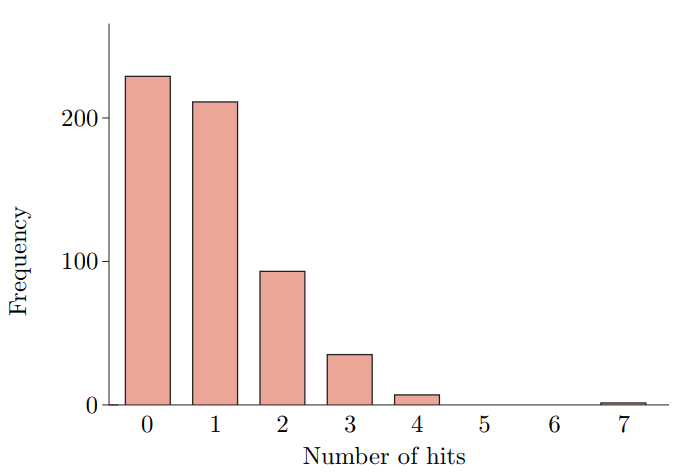

The investigators looked at whether the distribution of the number of hits in a grid square was consistent with the hits being randomly located in the large 6 km by 6 km square.

A model was required for the number of hits in a grid square assuming that the bombs landed in random positions. As a first step towards developing such a model, each grid square was in turn subdivided into 900 ‘crater’ squares. As suggested by the name, each of these squares was roughly the size of the crater made by a V-1 bomb. No crater square within the 6 km by 6 km square of South London suffered more than one hit.

**Modelling assumptions**
1. A hit at one point is no more likely than a hit at any other point. In other words, the probability that a crater square suffers a hit is constant from square to square.
2. Where a bomb lands is not influenced in any way by where any other bomb lands. That is, whether or not a particular crater square is hit is independent of whether or not any other crater square is hit.
3. There is a negligible chance of a bomb dropping into an existing crater. In other words, each crater square suffers at most one hit.

Together these assumptions mean that the outcomes (a hit or not a hit) for the 900 crater squares in a grid square may be regarded as 900 independent Bernoulli trials with constant probability of success (a hit). So since the average number of hits per grid square was 0.932, the number of hits in a grid square may be modelled by a binomial distribution with parameters n = 900 and p = 0.932/900 ≃ 0.00104.

## Computer activity 33: Models for the V-1 datan?

**The Poisson Limit Theorem** <br>
The approximation of the Binomial distribution using the Poisson distribution is known as the Poisson Limit Theorem:

1. Where $n$ is the number of trials is very large
2. Where $p$ is the probability is very small i.e. close to 0 usually $p \leq 0.05$

The Poisson distribution is derived from the Binomial distribution where one of the Binomial paramters $p$ from $B(n,p)$ is wrtitten as $p = \lambda / n$ where $\lambda > 0$. In the Binomial distribution the mean is calculated as $\mu = n \times p$ and in the Poisson distribution $\lambda = n \times p$ represents the average number of occurances.


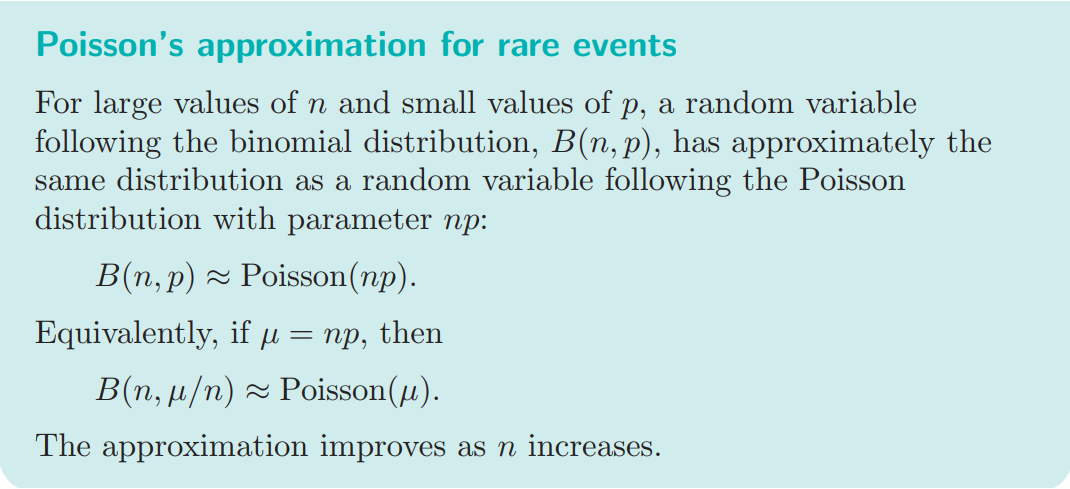

The Python script below displays graphically the number of V-1 bombs that hit a grid square from the observed data (remembering that each grid square is further subdivided into 900 crater squares where each crater is assumed to occur only once from a dropped bomb).

This is plotted against a binomial distribution using the parameters from the observed data i.e $n$ = variable number of hits and $p$ = 0.932 i.e. the average number of hits per grid square.

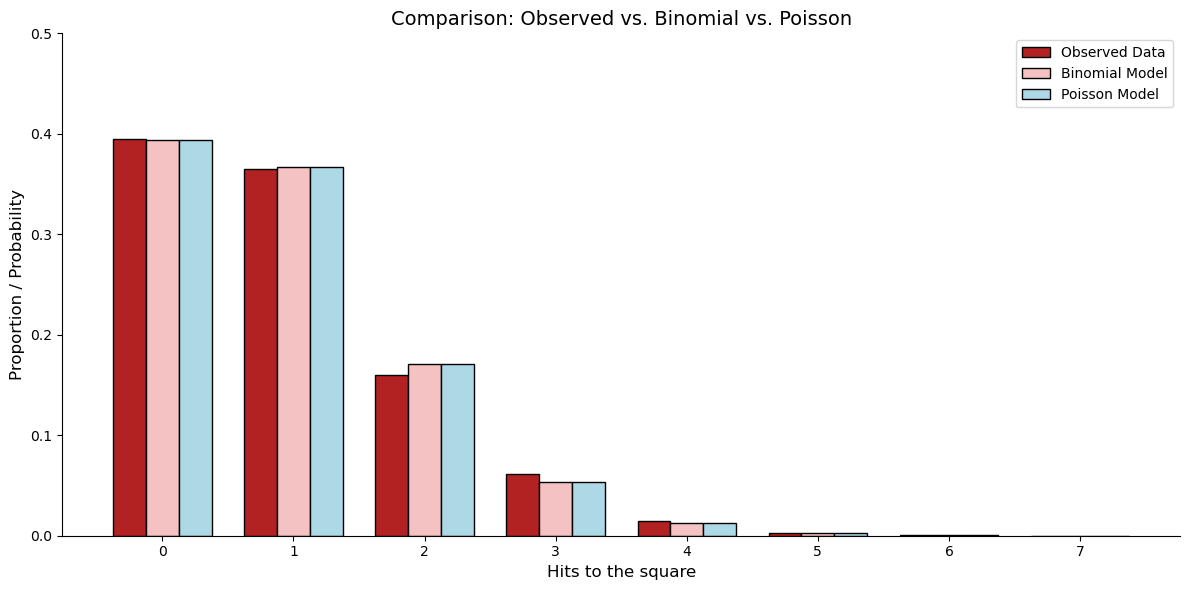

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom, poisson

# 1. Parameters from the visual model
n = 2000
mu = 0.932
p = mu / n
k_values = np.arange(0, 8)

# 2. Estimated Observed Proportions
observed_data = [0.395, 0.365, 0.160, 0.061, 0.015, 0.003, 0.001, 0.000]

# 3. Model Calculations
binom_probs = binom.pmf(k_values, n, p)
poisson_probs = poisson.pmf(k_values, mu)

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 6))
width = 0.25  # Narrower bars to fit three side-by-side
index = np.arange(len(k_values))

# Observed Data (Deep Red)
ax.bar(index - width, observed_data, width, label='Observed Data', color='#b22222', edgecolor='black')

# Binomial Model (Pink)
ax.bar(index, binom_probs, width, label='Binomial Model', color='#f4c2c2', edgecolor='black')

# Poisson Model (Light Blue)
ax.bar(index + width, poisson_probs, width, label='Poisson Model', color='#add8e6', edgecolor='black')

# 5. Styling
ax.set_xlabel('Hits to the square', fontsize=12)
ax.set_ylabel('Proportion / Probability', fontsize=12)
ax.set_title('Comparison: Observed vs. Binomial vs. Poisson', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(k_values)
ax.set_ylim(0, 0.5)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Commentary 

Firstly, the histogram of the observed data fits the binomial model very well which suggests that the distribution of the V-1 bomb hits follow a truly random pattern instead of being target weapons. Hence it can be conlcuded that the V-1 bombs were not particularly accurate weapons.

The tight fitting of the observed data with the binomial model is especially true when $n$ the number of hits is very large. However, when the number of hits $n$ is small the model deviates slightly from the observed data as can be seen in the below snapshot for $n$ = 10 for example:

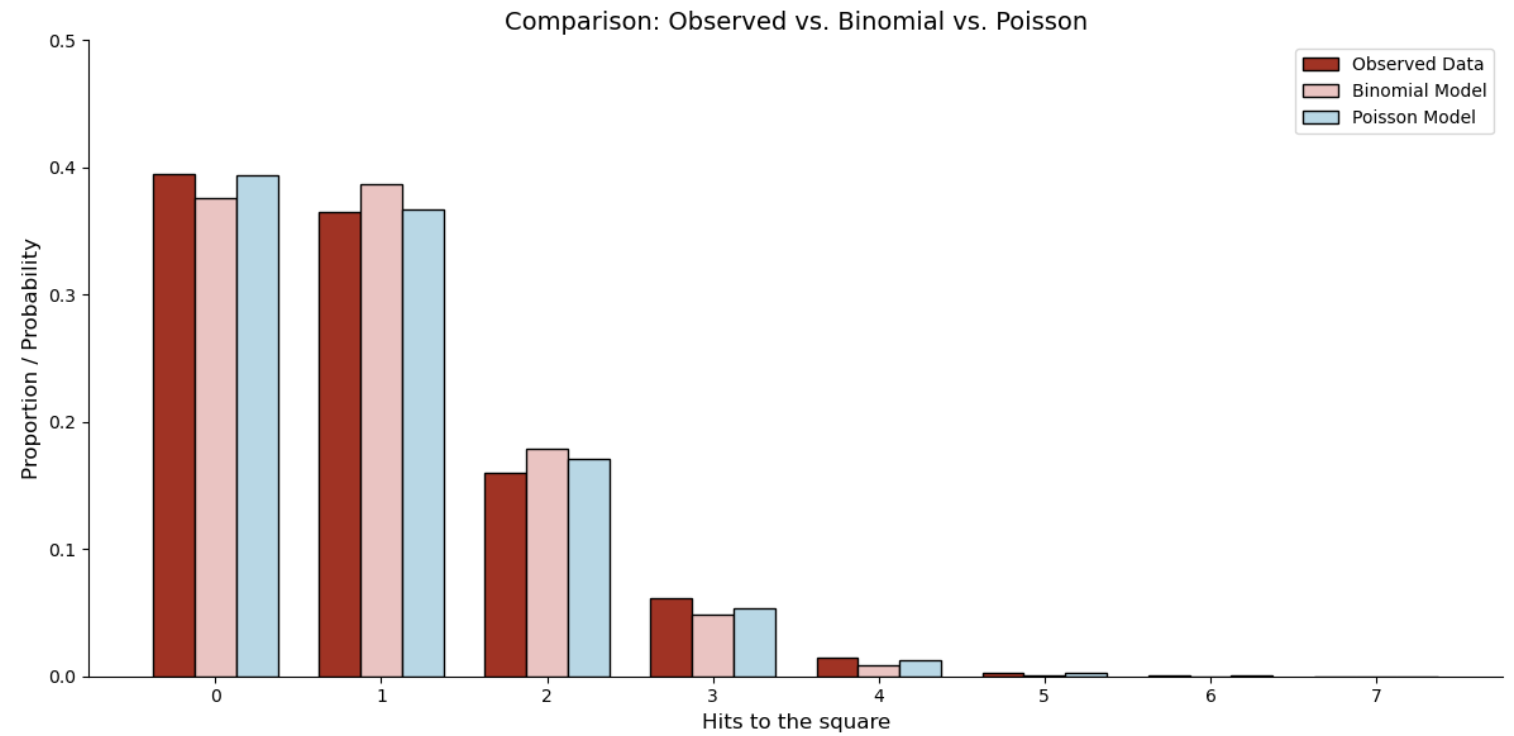

Lastly, the poisson model is a good approximation for the binomial model as can be seen in the above snapshot. The poisson model also fits the observed data very well for large $n$ as per the poisson Limit Theorem.

Since the poisson model is a good approximation for the binomial model for very large $n$ the advantages of the poisson model over the binomial model is that it would be too cumbersome (or uncomputable on a ordinary calculator) to calculate the binomial coefficient for some thing like $\binom{1000}{5}$ e.g. how many ways we can choose 5 items from a set of 1,000 items.

In [5]:
import math

# Calculate 1000 choose 5
result = math.comb(1000, 5)

print(f"The binomial coefficient is: {result:,}")

The binomial coefficient is: 8,250,291,250,200


This is analogous to the odds of winning the National Lottery i.e. from a set of 49 numbers what are the different ways of choosing the 6 winning numbers required for the jackpot. One would need to buy around 14 million lottery tickets to guarantee a jackpot.

In [6]:
import math

# Calculate 1000 choose 5
result = math.comb(49, 6)

print(f"The binomial coefficient is: {result:,}")

The binomial coefficient is: 13,983,816


So rather than calcuate the binomial coefficient required for the binomial model it would be much easier and straighforward to use the poisson model instead (where $n$ is very large and $p$ is very small).

## Computer activity 34: Good approximations

Both the binomial probability distribution and the poisson probability distribution both effectively use the same parameters where: $B(n, p) \approx \operatorname{Poisson}(np)$ and $\mu = np$. 

So for example as $n$ gets larger $p$ should get smaller and the poisson probability distribution is approximately the same as the binomial probability distribution. When $n$ is small $p$ becomes larger and $B(n, p) \approx \operatorname{Poisson}(np)$ and is no longer true.

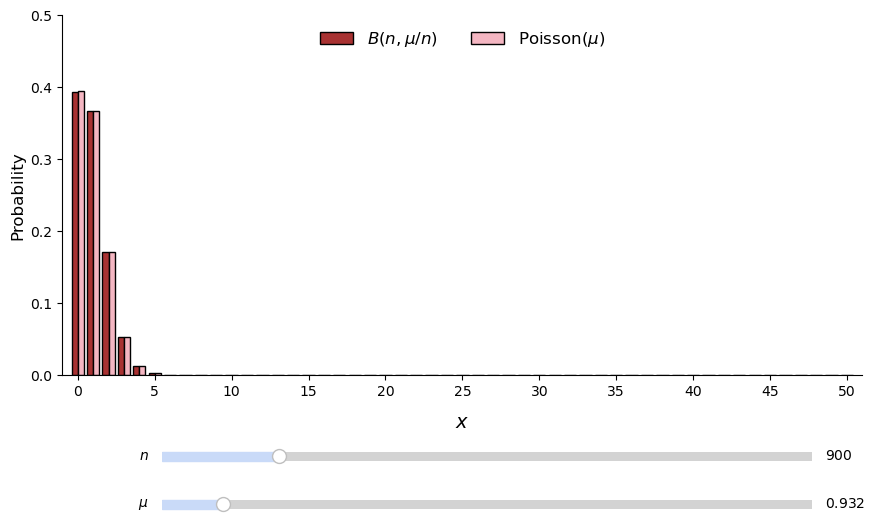

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, TextBox
from scipy.stats import binom, poisson

# 1. Set up initial values
initial_n = 900
initial_mu = 0.932
max_x = 50  # Maximum x-range shown on the x-axis

# 2. Create the figure and main plot axes
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.3)

# Initial data
x = np.arange(0, max_x + 1)
p = initial_mu / initial_n
y_binom = binom.pmf(x, initial_n, p)
y_poiss = poisson.pmf(x, initial_mu)

# 3. Bar width and positions for side-by-side bars
bar_width = 0.4
rects1 = ax.bar(x - bar_width / 2, y_binom, width=bar_width, 
                color='#a83232', edgecolor='black', label=r'$B\left(n, \mu/n\right)$')
rects2 = ax.bar(x + bar_width / 2, y_poiss, width=bar_width, 
                color='#f4b6c2', edgecolor='black', label=r'$\mathrm{Poisson}(\mu)$')

# 4. Styling the graph
ax.set_xlim(-1, max_x + 1)
ax.set_ylim(0, 0.5)
ax.set_xlabel(r'$x$', fontsize=14, labelpad=10)
ax.set_ylabel('Probability', fontsize=12)
ax.set_xticks(np.arange(0, max_x + 1, 5))
ax.legend(loc='upper center', frameon=False, ncol=2, fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. Define slider axes positions [left, bottom, width, height]
ax_n = plt.axes([0.2, 0.15, 0.65, 0.03])
ax_mu = plt.axes([0.2, 0.07, 0.65, 0.03])

# Sliders for n and mu
slider_n = Slider(ax_n, '$n$ ', 5, 5000, valinit=initial_n, valstep=1, color='#c9daf8')
slider_mu = Slider(ax_mu, r'$\mu$ ', 0.001, 10.0, valinit=initial_mu, valstep=0.001, color='#c9daf8')

# 6. Update function when sliders are changed
def update(val):
    current_n = int(slider_n.val)
    current_mu = slider_mu.val
    
    current_p = current_mu / current_n
    
    # Calculate updated probabilities
    new_y_binom = binom.pmf(x, current_n, current_p)
    new_y_poiss = poisson.pmf(x, current_mu)
    
    # Update heights of the bars
    for rect, h in zip(rects1, new_y_binom):
        rect.set_height(h)
    for rect, h in zip(rects2, new_y_poiss):
        rect.set_height(h)
        
    # Dynamically adjust y-axis maximum so bars stay clearly visible
    max_prob = max(np.max(new_y_binom), np.max(new_y_poiss))
    ax.set_ylim(0, max(0.5, max_prob * 1.15))
    
    fig.canvas.draw_idle()

slider_n.on_changed(update)
slider_mu.on_changed(update)

plt.show()

### Commentary 

What determines how well the poisson probability distribution approximates the binomial probability distribution is $n$ and $p$. Adjusting $\mu$ does change the shape of both distributions however it would seem that $n$ is a strong determining factor in determining if $B(n, p) \approx \operatorname{Poisson}(np)$ is true


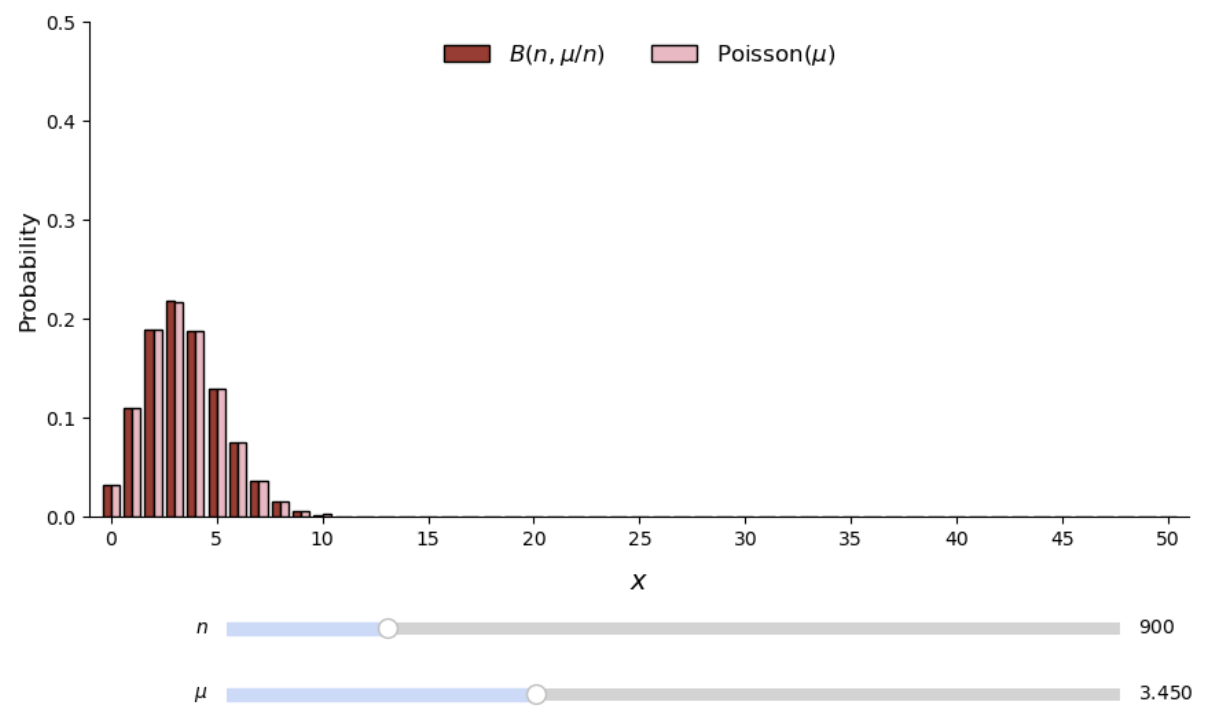
*Where $\mu$ has been adjusted and $n$ is large the bars for the poisson probability distribution and binomial probability distribution are approximately the same size*

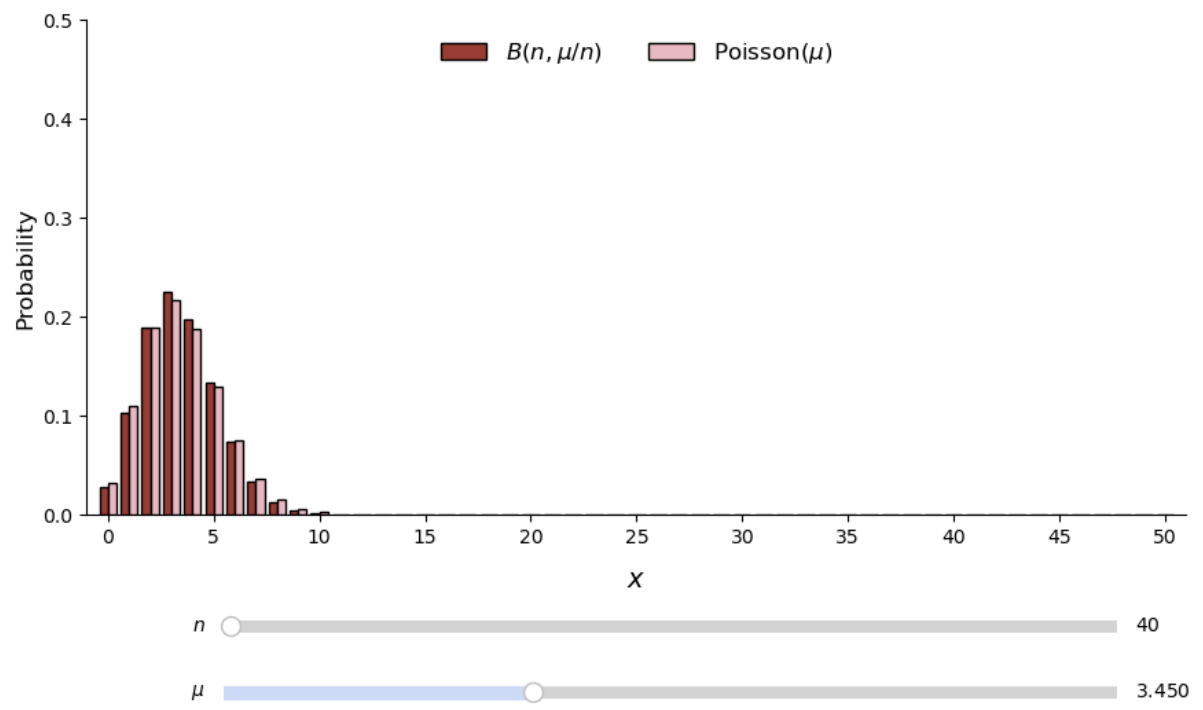
*Where $\mu$ has been adjusted and $n$ is small the bars for the poisson probability distribution and binomial probability distribution are no longer approximately the same size*

The next section will show that for the approximation $B(n, p) \approx \operatorname{Poisson}(np)$ to remain close:
1. Large values of $n$ and small values of $p$ are sufficient
2. However, when $n$ is small then if $p$ is small enough that is also sufficient

## Computer activity 35: More on approximations

The plot below shows the probability distributions for the V-1 bombs using the poisson and binomial distributions with parameters $n$ = 50 and $p$ = 0.2. For these parameters the poisson distribution is not a good approximation for the binomial model. Parameters that fit the poisson distribution model with the binomial distribution model are discussed below.

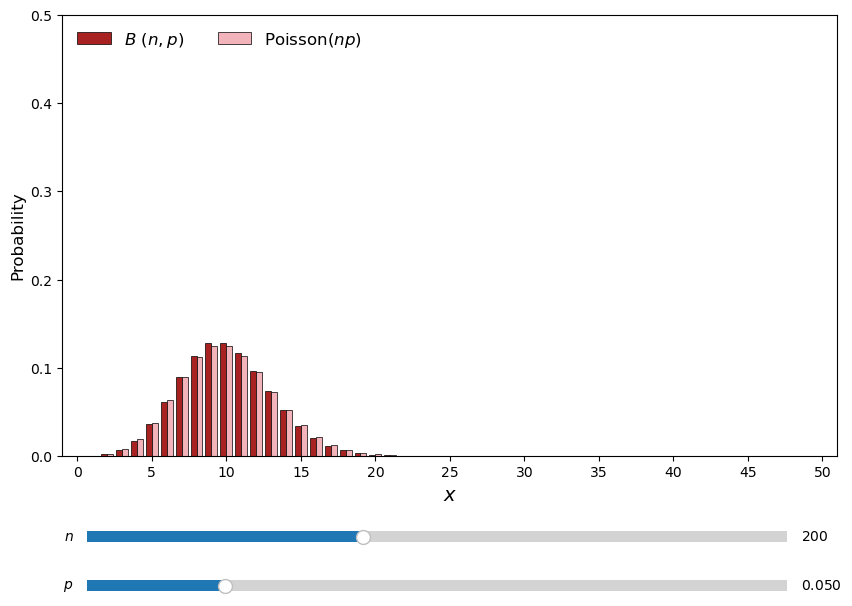

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy.stats import binom, poisson

# Initial values
init_n = 200
init_p = 0.05
x_max = 50
x = np.arange(0, x_max + 1)
bar_width = 0.4

# Setup figure and layout
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.25)

# Calculate initial probabilities
p_binom = binom.pmf(x, init_n, init_p)
p_poisson = poisson.pmf(x, init_n * init_p)

# Initial bar plots
bars_binom = ax.bar(x - bar_width/2, p_binom, width=bar_width, 
                    color='#a82222', edgecolor='black', linewidth=0.5, label=r'$B\ (n, p)$')
bars_poisson = ax.bar(x + bar_width/2, p_poisson, width=bar_width, 
                      color='#f3b3ba', edgecolor='black', linewidth=0.5, label=r'$\mathrm{Poisson}(np)$')

ax.set_xlim(-1, x_max + 1)
ax.set_ylim(0, 0.5)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel('Probability', fontsize=12)
ax.set_xticks(np.arange(0, x_max + 1, 5))
ax.legend(loc='upper left', frameon=False, fontsize=12, ncol=2)

# Add Slider axes
ax_n = plt.axes([0.15, 0.12, 0.7, 0.03])
ax_p = plt.axes([0.15, 0.05, 0.7, 0.03])

# Create Sliders
slider_n = Slider(ax_n, '$n$', 5, 500, valinit=init_n, valstep=1)
slider_p = Slider(ax_p, '$p$', 0.001, 0.25, valinit=init_p)

# Update function for sliders
def update(val):
    current_n = int(slider_n.val)
    current_p = slider_p.val
    
    new_binom = binom.pmf(x, current_n, current_p)
    new_poisson = poisson.pmf(x, current_n * current_p)
    
    for b_b, b_p, h_b, h_p in zip(bars_binom, bars_poisson, new_binom, new_poisson):
        b_b.set_height(h_b)
        b_p.set_height(h_p)
        
    fig.canvas.draw_idle()

slider_n.on_changed(update)
slider_p.on_changed(update)

plt.show()

### Commentary 

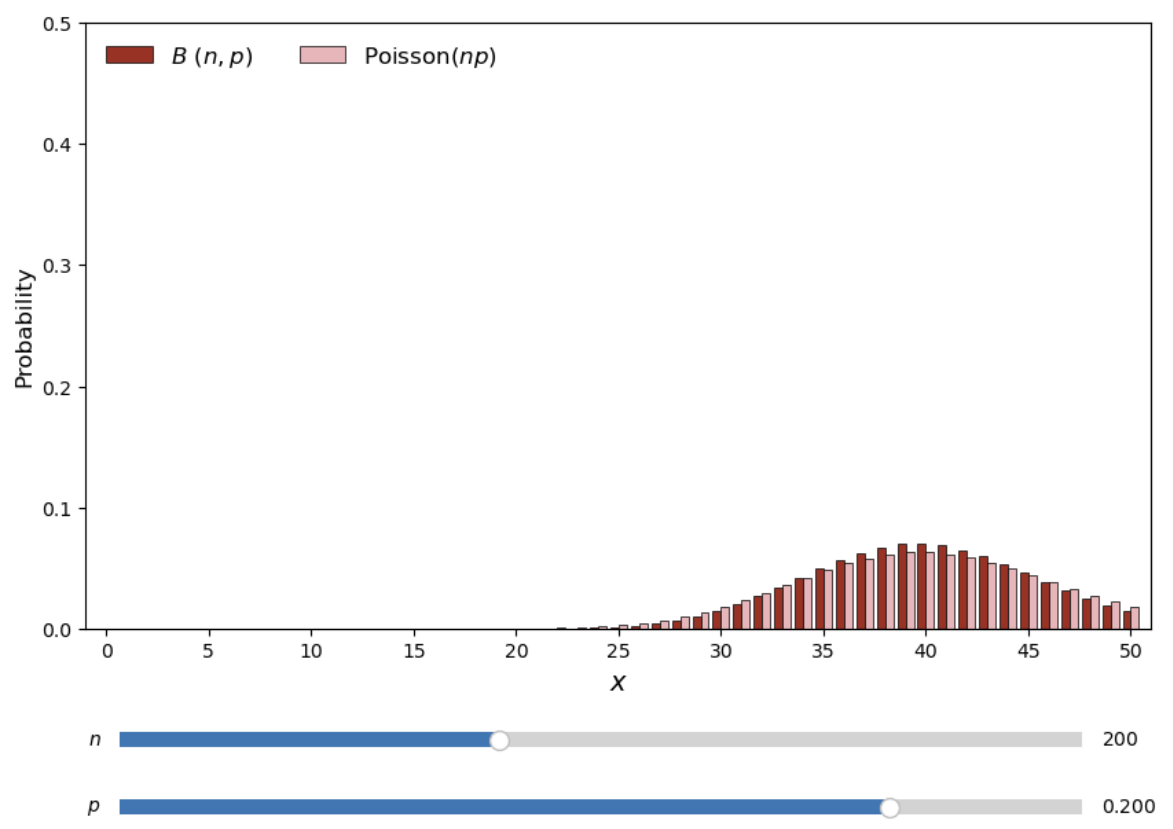
*When n is increased from 50 to 200 but p kept constant the posisson distribution fits the binomial distribution a little better*

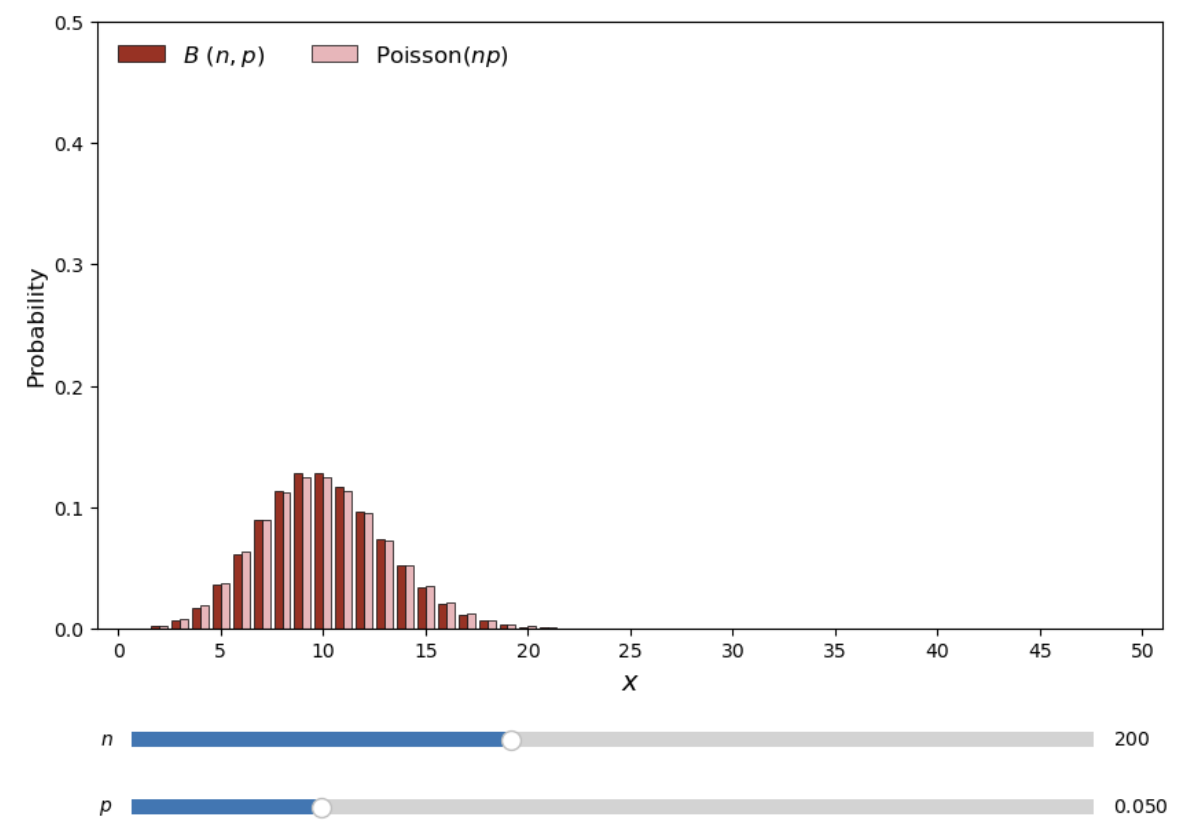
*When n is kept constant at 200 but then p is reduced to a very samll of 0.05 the posisson distribution fits the binomial distribution even more*

A good rule of thumb for when $B(n, p) \approx \operatorname{Poisson}(np)$ is as follows:
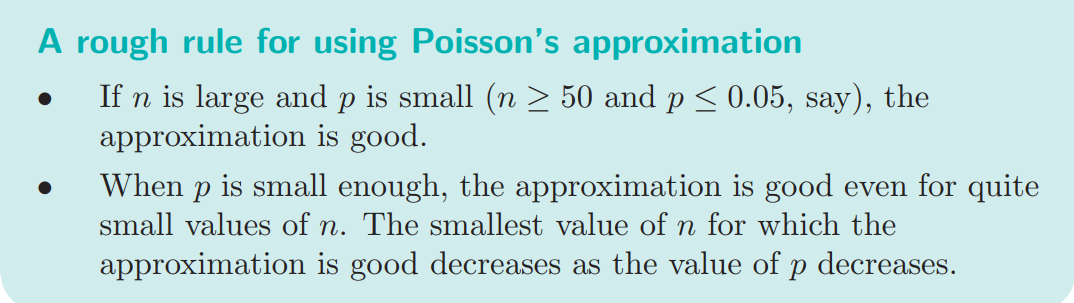